# Pronósticos basados en series de tiempo
## Diego Fernando Agudelo
## Universidad Javeriana- Cali
## diegoagudelo30@gmail.com

## **1. Carga de paquetes**

In [9]:
import pandas as pd
import numpy as np
from statsmodels.sandbox.stats.runs import runstest_1samp # prueba de rachas de Wald y Wolfowitz
import statsmodels.api as sm # prueba de Box-Pierce y la modificación de Ljung-Box
from matplotlib import pyplot as plt # gráficos
import pylab as py
from scipy import stats
from datetime import datetime
from dateutil.relativedelta import relativedelta
from statsmodels.graphics.tsaplots import plot_acf

## **2. Carga de datos**

Vamos a usar los siguientes datos para validar las diferentes pruebas.

In [14]:
# Crear el rezago de un periodo para la serie Ocupados
data["Ocupados_lag1"] = data["Ocupados"].shift(1)

# Verificar que quedó creado
data[["Ocupados", "Ocupados_lag1"]].head()

,Ocupados,Ocupados_lag1
mes,,
2001-01-01,6923.604,NaN
2001-02-01,7037.746,6923.604
2001-03-01,6945.973,7037.746
2001-04-01,6973.079,6945.973
2001-05-01,6994.462,6973.079


(222, 5)


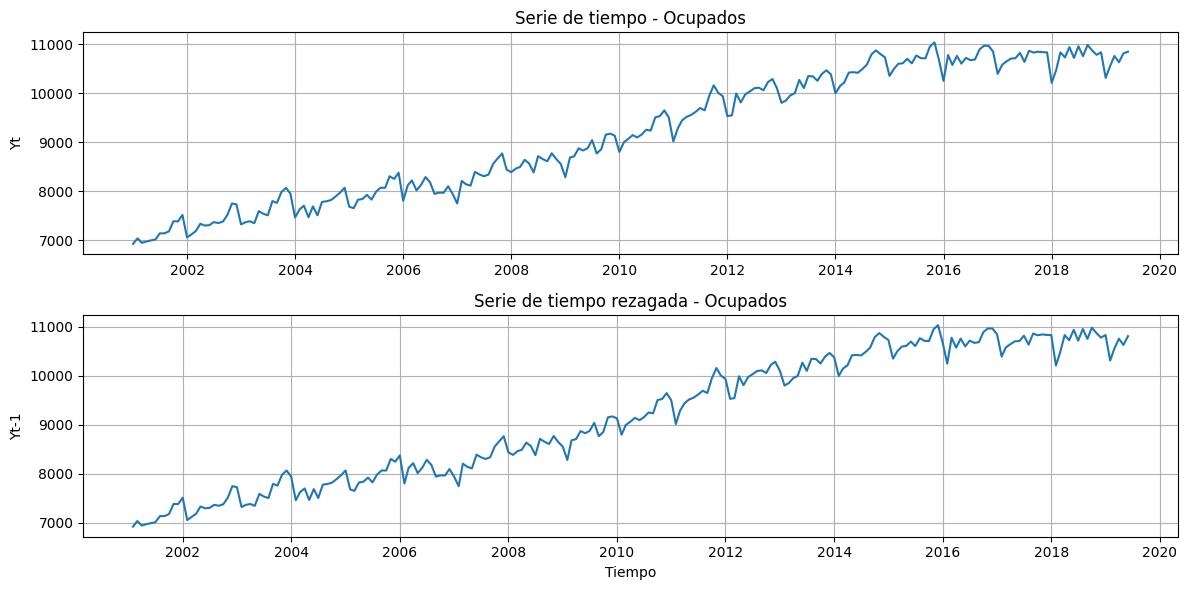

In [17]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
fig = plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.title("Serie de tiempo - Ocupados")
plt.ylabel("Yt")
plt.plot(data[["Ocupados"]])
plt.grid()

plt.subplot(2, 1, 2)
plt.title("Serie de tiempo rezagada - Ocupados")
plt.xlabel("Tiempo")
plt.ylabel("Yt-1")
plt.plot(data[["Ocupados_lag1"]])
plt.grid()

plt.tight_layout()
plt.show()

Al graficar la serie de ocupados y su rezago de un periodo, se observa que ambas mantienen un comportamiento similar en el tiempo, presentan una tendencia creciente, por lo que no se comporta como ruido blanco.

## **3. Autocorrelación**

Para determinar si existe autocorrelación vamos a usar la prueba de rachas propuesta por Wald y Wolfowitz, 1940. Es una prueba no paramétrica donde las hipótesis son las siguientes:

$H{0}: ρ = 0$ (Es decir no hay autocorrelación)

$H{1}: ρ \not= 0$ (Es decir hay autocorrelación)

Rechazo $H{0}$ cuando el p-valor es menor al nivel de significancia, convencionalmente se usa un $α$=0.05 ($α$ = nivel de significancia).


In [21]:
from statsmodels.sandbox.stats.runs import runstest_1samp

# Signos respecto a la mediana
signo = data["Ocupados"] > data["Ocupados"].median()

# Prueba de corridas Wald-Wolfowitz
runstest_1samp(signo, correction=False)

(np.float64(-13.991737353478094), np.float64(1.7508200258769353e-44))

Como en este caso la serie Ocupados presenta todos los valores positivos, procedemos a compararla contra su mediana y no contra 0. El segundo valor corresponde al p-valor de casi 0, por lo tanto considerando un $α$=0.05, los resultados obtenidos permiten rechazar la hipótesis nula, es decir, la serie Ocupados no se comporta como un ruido blanco, **presenta autocorrelación**.

In [22]:
# Signos respecto a la mediana
signo = data["Ocupados_lag1"] > data["Ocupados_lag1"].median()

# Prueba de corridas Wald-Wolfowitz
runstest_1samp(signo, correction=False)

(np.float64(-13.99166607482073), np.float64(1.752575845938607e-44))

Los resultados permiten rechazar la no autocorrelación (p-value=0) y por lo tanto se puede concluir que existe autocorrelación en la serie.

Este análisis debe complementarse con otras pruebas como la prueba de Box-Pierce y la modificación de Ljung-Box para muestras pequeñas.

In [23]:
# prueba de Box-Pierce y la modificación de Ljung-Box
sm.stats.acorr_ljungbox(data.Ocupados, lags=[1], return_df=True,boxpierce=True ) # Se puede hacer para un solo lag.

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,215.466151,8.818153e-49,212.580444,3.757527e-48


Con el resultado anterior rechazamos la hipótesis nula de no autocorrelación para el primer rezago, ya que son practicamente 0. Si existe autocorrelación.

In [24]:
# Prueba de Box-Pierce y Ljung-Box para los primeros 24 rezagos

Resul_lb_bp = sm.stats.acorr_ljungbox(
    data["Ocupados"],
    lags=range(1, 25),
    return_df=True,
    boxpierce=True
)

Resul_lb_bp["lb_ho"] = np.where(
    Resul_lb_bp["lb_pvalue"] < 0.05,
    "rechazo_ho/hay_autocorr",
    "no_rechazo_ho/no_hay_autocorr"
)

Resul_lb_bp["bp_ho"] = np.where(
    Resul_lb_bp["bp_pvalue"] < 0.05,
    "rechazo_ho/hay_autocorr",
    "no_rechazo_ho/no_hay_autocorr"
)

Resul_lb_bp

,lb_stat,lb_pvalue,bp_stat,bp_pvalue,lb_ho,bp_ho
1,215.466151,8.818153e-49,212.580444,3.757527e-48,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
2,425.045838,5.040446e-93,418.417636,1.386005e-91,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
3,629.973395,3.201138e-136,618.770917,8.590288e-134,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
4,830.534686,1.866623e-178,813.960031,7.268819e-175,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
5,1028.006530,5.191558e-220,1005.260880,4.364213e-215,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
6,1222.035167,8.145806e-261,1192.359923,2.155332e-254,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
7,1412.841689,6.426069e-301,1375.500111,7.718370e-293,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
8,1599.512253,0.000000e+00,1553.837168,0.000000e+00,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
9,1782.749605,0.000000e+00,1728.076257,0.000000e+00,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
10,1963.258217,0.000000e+00,1898.914764,0.000000e+00,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr


Los resultados muestran rechazo de la hipótesis nula en los primeros 24 rezagos, tanto para Ljung-Box como para Box-Pierce. Esto confirma que la serie de ocupados presenta dependencia temporal y no se comporta como ruido blanco, **Si presenta autocorrelación**.

### **4. Homoscedasticidad y Heteroscedasticidad**

Ahora nos queda por chequear si existe problemas de heteroscedasticidad, en
especial un comportamiento tipo ARCH o GARCH, esto implica que la varianza de la serie tenga un comportamiento no autocorrelacionado.

Una aproximación para determinar si existe un comportamiento GARCH o
ARCH es emplear la prueba de Ljung-Box sobre la serie (sin media) al cuadrado.

$H{0}:$ Comportamiento Homoscedastico (Es decir varianza constante)

$H{1}:$ Comportamiento Heteroscedastico (Es decir varianza no constante)

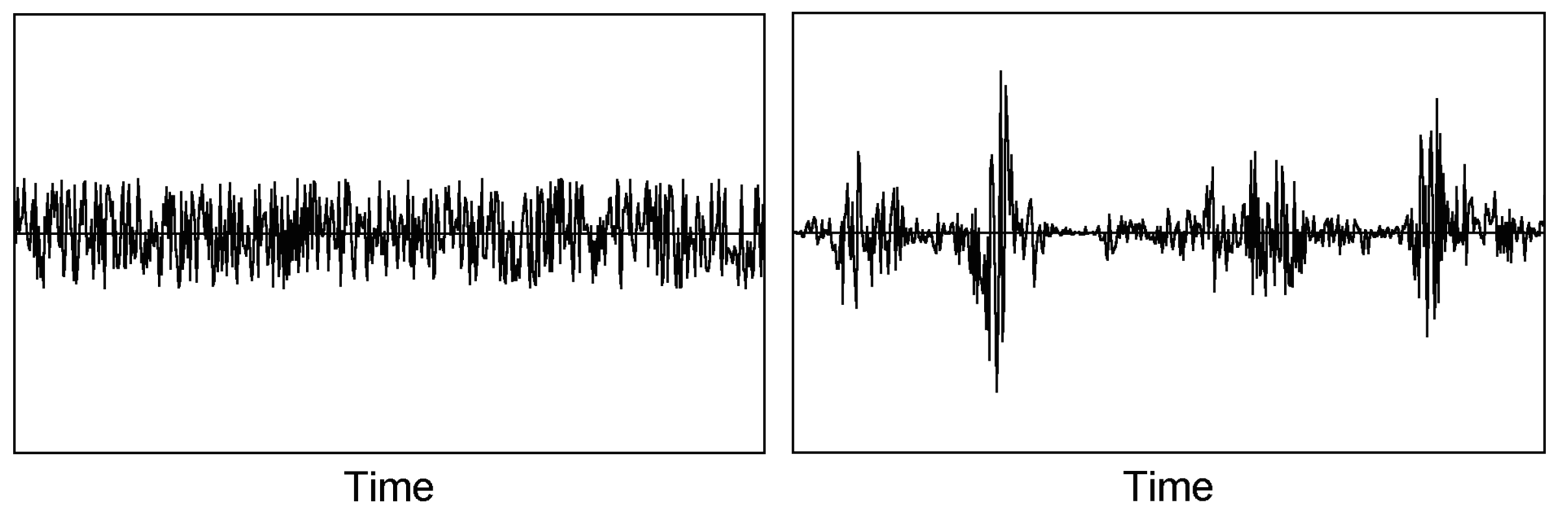



In [25]:
sm.stats.acorr_ljungbox((data.Ocupados-data.Ocupados.mean())**2, lags=range(1,25), return_df=True,boxpierce=True )

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,185.144285,3.650054e-42,182.664674,1.269512e-41
2,351.726827,4.202327e-77,346.272528,6.425041e-76
3,503.667333,7.654204e-109,494.821504,6.322880e-107
4,644.388355,3.822171e-138,631.773213,2.056334e-135
5,779.932738,2.537066e-166,763.081835,1.120126e-162
6,908.018395,6.939421e-193,886.593004,2.972305e-188
7,1033.010933,8.866253e-219,1006.563521,4.598527e-213
8,1150.214310,5.463849e-243,1118.534603,3.804834e-236
9,1265.945521,6.998913e-267,1228.582585,8.181347e-259
10,1382.954411,4.749866e-291,1339.323142,1.245900e-281


Los resultados de los valores p obtenidos en las pruebas de Ljung-Box y Box-Pierce aplicadas a la serie centrada al cuadrado son menores a 0.05, por lo que la serie presenta cambios en su variabilidad a lo largo del tiempo. Permiten rechazar la hipótesis nula de un comportamiento homoscedástico (no auto-correlación de las varianzas).

### **5. Normalidad**
Finalmente, podemos evaluar si la serie sigue una distribución normal o no. Noten que esto no es necesario para ser ruido blanco, solo para ser ruido blanco gaussiano. Primero hagamos un análisis gráfico empleando las siguientes lineas de código.

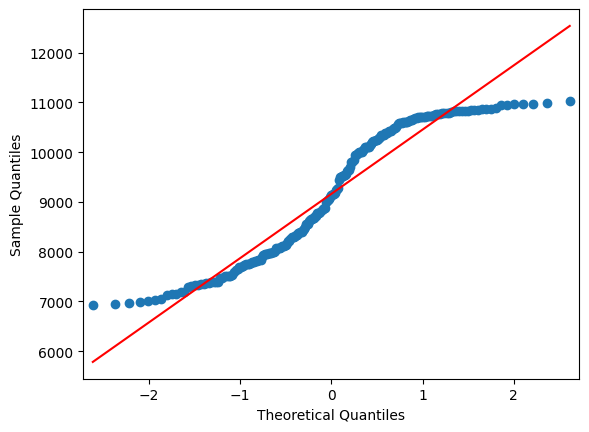

In [32]:
sm.qqplot(data.Ocupados, line ='s')
py.show()

En el grafico de la serie de ocupados se observa que los puntos no se ajustan completamente a la línea de referencia, esto sugiere que la distribución de la serie no es normal. Este resultado es coherente con el comportamiento observado anteriormente, ya que la serie presenta tendencia, autocorrelación y cambios en su variabilidad.

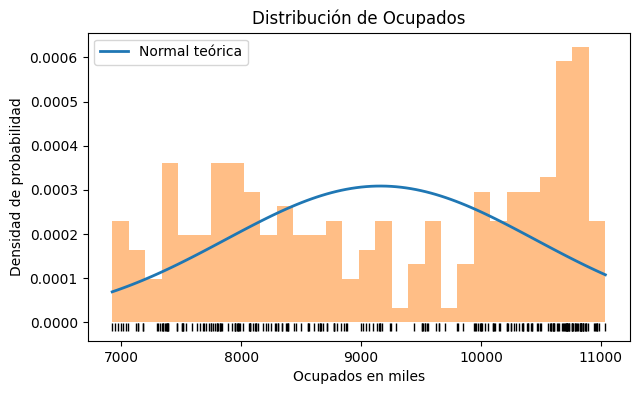

In [34]:
# Histograma + curva normal teórica
# ==================================

mu, sigma = stats.norm.fit(data["Ocupados"])

x_hat = np.linspace(min(data["Ocupados"]), max(data["Ocupados"]), num=100)
y_hat = stats.norm.pdf(x_hat, mu, sigma)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_hat, y_hat, linewidth=2, label="Normal teórica")
ax.hist(x=data["Ocupados"], density=True, bins=30, alpha=0.5)
ax.plot(data["Ocupados"], np.full_like(data["Ocupados"], -0.00001), "|k", markeredgewidth=1)

ax.set_title("Distribución de Ocupados")
ax.set_xlabel("Ocupados en miles")
ax.set_ylabel("Densidad de probabilidad")
ax.legend()

plt.show()

In [35]:
stats.shapiro(data.Ocupados)


ShapiroResult(statistic=np.float64(0.9111439682568433), pvalue=np.float64(3.039085379954234e-10))

In [36]:
stats.jarque_bera(data.Ocupados)

SignificanceResult(statistic=np.float64(20.11813814008792), pvalue=np.float64(4.2795865091983345e-05))

Para ambas pruebas, se rechaza la hipótesis nula de que los datos provienen de una distribución normal.

### **6. Tendencia Lineal**

In [37]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


In [38]:
y = data["Ocupados"]
x = np.linspace(1,data.shape[0],data.shape[0])
X = sm.add_constant(x)
lin = sm.OLS(y,X)
lin_t = lin.fit()
print(lin_t.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     4729.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          1.02e-150
Time:                        00:14:45   Log-Likelihood:                -1559.9
No. Observations:                 222   AIC:                             3124.
Df Residuals:                     220   BIC:                             3131.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6962.4958     36.871    188.835      0.0

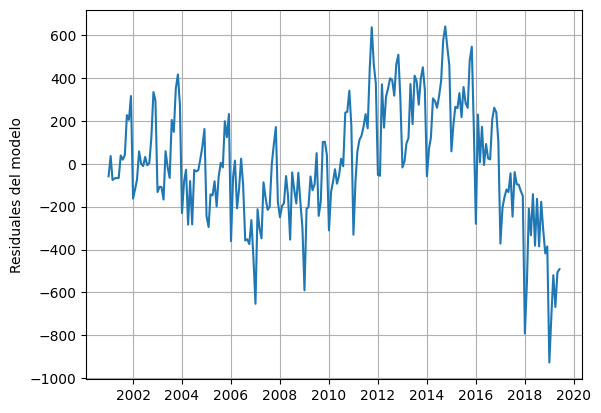

In [39]:
plt.ylabel("Residuales del modelo")
plt.plot(lin_t.resid)
plt.grid()

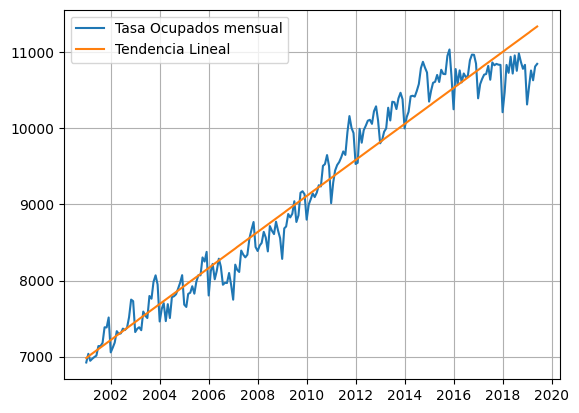

In [40]:
plt.plot(y,label="Tasa Ocupados mensual")
plt.plot(lin_t.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [42]:
h=6
x_for= np.linspace((data.shape[0]+1),(data.shape[0]+h),h)
X_for= sm.add_constant(x_for)


In [43]:
dt = lin_t.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    11359.208189  10814.820716  11903.595662
1    11378.924388  10834.471236  11923.377539
2    11398.640587  10854.121178  11943.159995
3    11418.356786  10873.770542  11962.943029
4    11438.072984  10893.419328  11982.726641
5    11457.789183  10913.067536  12002.510831


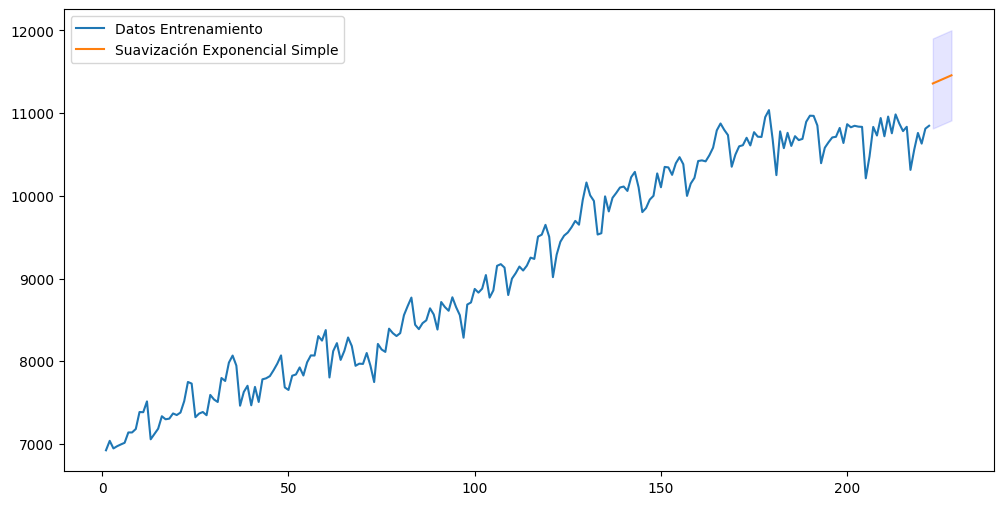

In [44]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()


### **7. Tendencia Cuadratica**

In [45]:
y = data["Ocupados"]
data["x"] = np.linspace(1,data.shape[0],data.shape[0])
data["x2"] = x**2
X = sm.add_constant(data[["x","x2"]])
pol = sm.OLS(y,X)
pol_2 = pol.fit()
print(pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     2560.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          1.33e-152
Time:                        00:26:00   Log-Likelihood:                -1551.0
No. Observations:                 222   AIC:                             3108.
Df Residuals:                     219   BIC:                             3118.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6790.8804     53.552    126.810      0.0

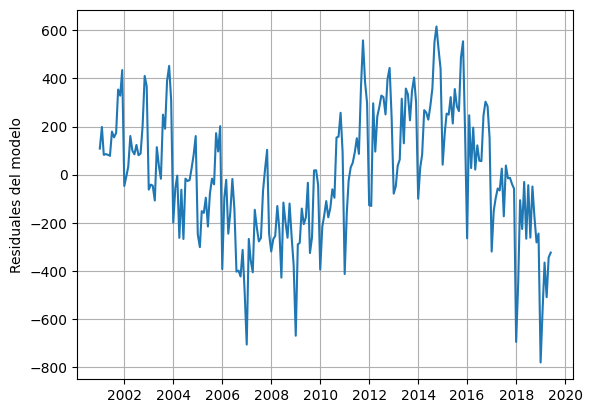

In [46]:
plt.ylabel("Residuales del modelo")
plt.plot(pol_2.resid)
plt.grid()

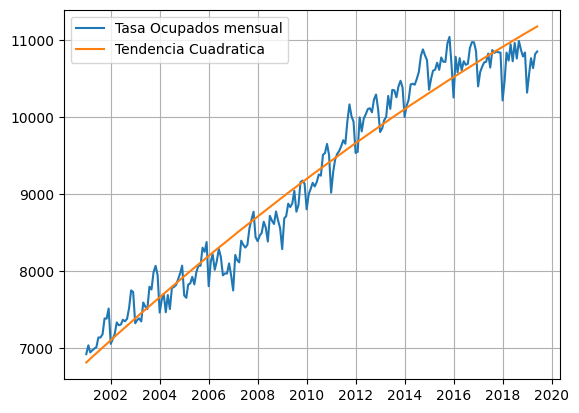

In [47]:
plt.plot(y,label="Tasa Ocupados mensual")
plt.plot(pol_2.fittedvalues,label="Tendencia Cuadratica")
plt.legend()
plt.grid()
plt.show()

In [48]:
h=6
x_for= np.linspace((data.shape[0]+1),(data.shape[0]+h),h)
X_for= sm.add_constant(np.stack((x_for, x_for**2), axis=1))

In [49]:
dt = pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    11187.592748  10657.511767  11717.673730
1    11202.691491  10672.226911  11733.156072
2    11217.749007  10686.889054  11748.608961
3    11232.765296  10701.497992  11764.032599
4    11247.740357  10716.053522  11779.427192
5    11262.674191  10730.555438  11794.792944


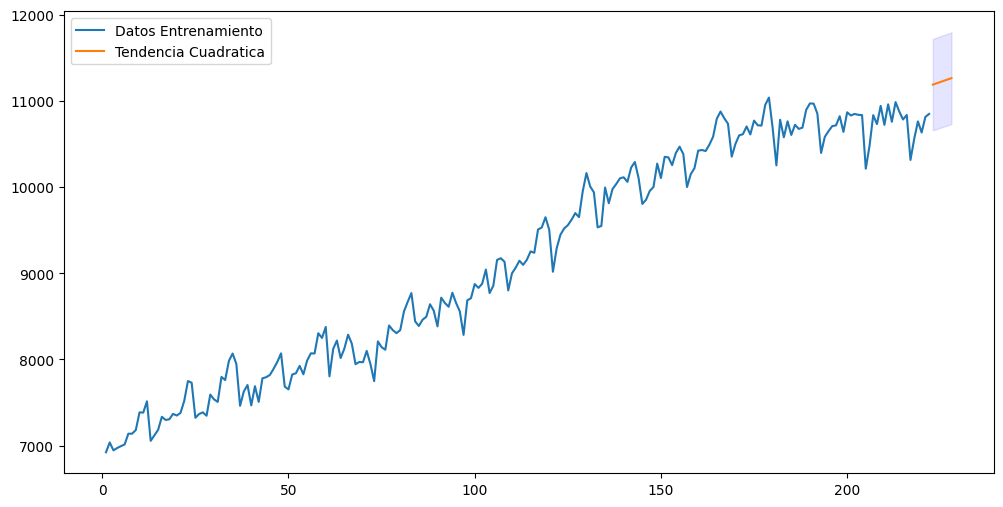

In [50]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Tendencia Cuadratica")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

### **8. Estimación de la Estacionalidad**

In [51]:
month_dummies = pd.get_dummies(data.index.month,drop_first=True, dtype=float).set_index(data.index)

y = data["Ocupados"]
X = sm.add_constant(month_dummies)
sea = sm.OLS(y,X)
season = sea.fit()
print(season.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.038
Method:                 Least Squares   F-statistic:                    0.2687
Date:                Wed, 10 Jun 2026   Prob (F-statistic):              0.991
Time:                        00:33:13   Log-Likelihood:                -1903.9
No. Observations:                 222   AIC:                             3832.
Df Residuals:                     210   BIC:                             3873.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8808.2176    302.768     29.092      0.0

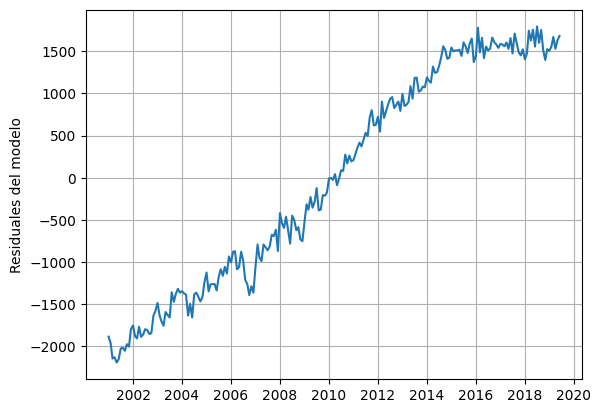

In [52]:
plt.ylabel("Residuales del modelo")
plt.plot(season.resid)
plt.grid()

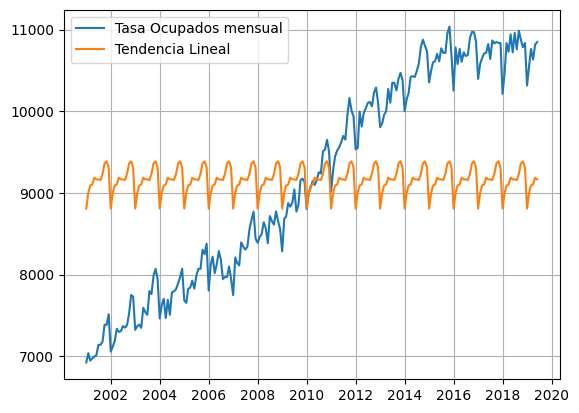

In [53]:
plt.plot(y,label="Tasa Ocupados mensual")
plt.plot(season.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [63]:
range_dates = pd.date_range(data.index[-1]+ relativedelta(months=11), periods=6,freq='MS')

x_for = pd.get_dummies(range_dates.month,drop_first=True, dtype=float)
x_for = x_for.reindex(columns=month_dummies.columns, fill_value=0)

X_for = sm.add_constant(x_for, has_constant='add')


            Point_forecast     lower_95      upper_95
2020-05-01     8808.217632  6139.005354  11477.429909
2020-06-01     9165.273789  6496.061512  11834.486067
2020-07-01     9164.935167  6492.018221  11837.852112
2020-08-01     9156.633500  6483.716554  11829.550446
2020-09-01     9232.988500  6560.071554  11905.905446
2020-10-01     9359.934944  6687.017999  12032.851890


Al construir el modelo estacional se utilizaron variables dummy para representar los meses del año. Debido a que se usó drop_first=True, el modelo se estima con 11 variables dummy más la constante. Al generar el pronóstico para los siguientes 6 meses, las variables dummy futuras no necesariamente contienen todas las columnas usadas en el entrenamiento, sino únicamente las correspondientes a los meses planteados inicialmente. Por esta razón, fue necesario reindexar las dummies futuras con las mismas columnas del modelo original y completar con cero aquellas que no aparecen en el periodo de pronóstico. Asi se garantiza que la matriz de predicción tenga la misma estructura que la matriz utilizada para ajustar el modelo.

In [64]:
dt = season.get_prediction(X_for).summary_frame(alpha=0.05)

y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']

preds = pd.DataFrame(
    np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]),
    columns=['Point_forecast', 'lower_95', 'upper_95'],
    index=range_dates
)

print(preds)

            Point_forecast     lower_95      upper_95
2020-05-01     8808.217632  6139.005354  11477.429909
2020-06-01     9165.273789  6496.061512  11834.486067
2020-07-01     9164.935167  6492.018221  11837.852112
2020-08-01     9156.633500  6483.716554  11829.550446
2020-09-01     9232.988500  6560.071554  11905.905446
2020-10-01     9359.934944  6687.017999  12032.851890


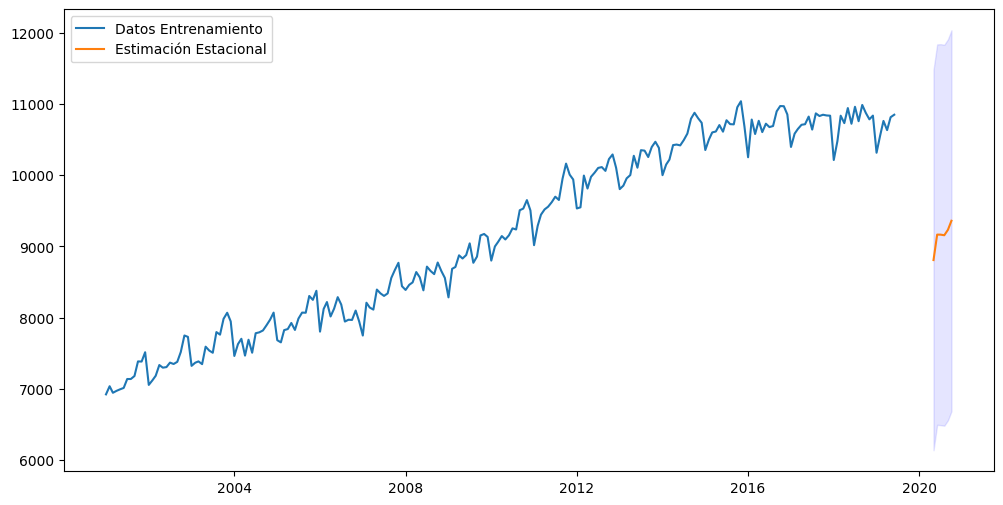

In [65]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

### **9. Tendencia + Estacionalidad**

In [75]:
y = data["Ocupados"]
data["x"] = np.linspace(1,data.shape[0],data.shape[0])
data["x2"] = x**2

month_dummies = pd.get_dummies(data.index.month,drop_first=True, dtype=float).set_index(data.index)
X = sm.add_constant( pd.concat([data[["x","x2"]],month_dummies],axis=1) )

season_pol2 = sm.OLS(y,X)
season_pol_2 = season_pol2.fit()
print(season_pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     502.6
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          3.33e-149
Time:                        01:11:21   Log-Likelihood:                -1519.4
No. Observations:                 222   AIC:                             3067.
Df Residuals:                     208   BIC:                             3114.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6508.3401     69.460     93.700      0.0

In [76]:
X

,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,,,,
2001-01-01,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-02-01,1.0,2.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-03-01,1.0,3.0,9.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-04-01,1.0,4.0,16.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-05-01,1.0,5.0,25.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-02-01,1.0,218.0,47524.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-03-01,1.0,219.0,47961.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-04-01,1.0,220.0,48400.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


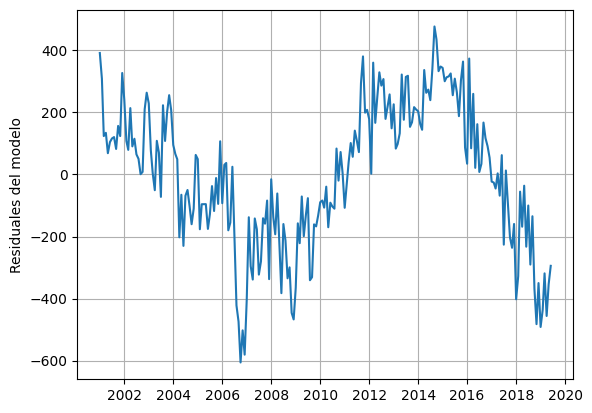

In [77]:
plt.ylabel("Residuales del modelo")
plt.plot(season_pol_2.resid)
plt.grid()

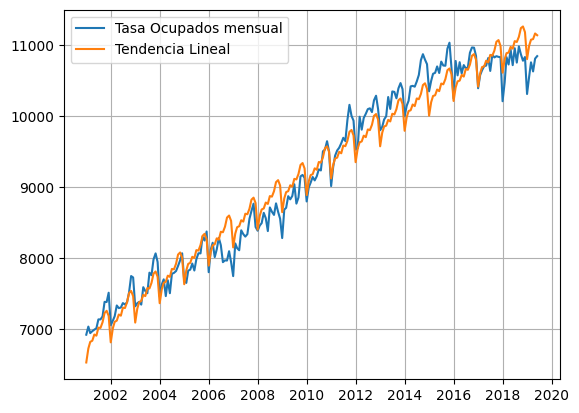

In [78]:
plt.plot(y,label="Tasa Ocupados mensual")
plt.plot(season_pol_2.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [79]:
h=6
x_for= np.linspace((data.shape[0]+1),(data.shape[0]+h),h)
x_for_all = pd.DataFrame(np.stack((x_for, x_for**2),axis=1),columns=["x","x2"] )

range_dates = pd.date_range(data.index[-1]+ relativedelta(months=1), periods=h,freq='MS')
x_for_dummies = pd.get_dummies(range_dates.month,drop_first=True, dtype=float)
x_for_dummies = x_for_dummies.reindex(columns=month_dummies.columns,fill_value=0)

X_for = sm.add_constant(pd.concat([x_for_all.reset_index(drop=True),x_for_dummies.reset_index(drop=True)],axis=1),has_constant='add')
X_for = X_for.reindex(columns=X.columns, fill_value=0)

X_for


,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
0,1.0,223.0,49729.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
1,1.0,224.0,50176.0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0
2,1.0,225.0,50625.0,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0
3,1.0,226.0,51076.0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0
4,1.0,227.0,51529.0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0
5,1.0,228.0,51984.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0


In [80]:
dt = season_pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast      lower_95      upper_95
2019-07-01    10899.308298  10416.761632  11381.854965
2019-08-01    11234.988869  10750.954256  11719.023481
2019-09-01    11307.022964  10822.688332  11791.357595
2019-10-01    11429.648504  10945.006353  11914.290654
2019-11-01    11452.094877  10967.137722  11937.052032
2019-12-01    11371.404416  10886.124786  11856.684047


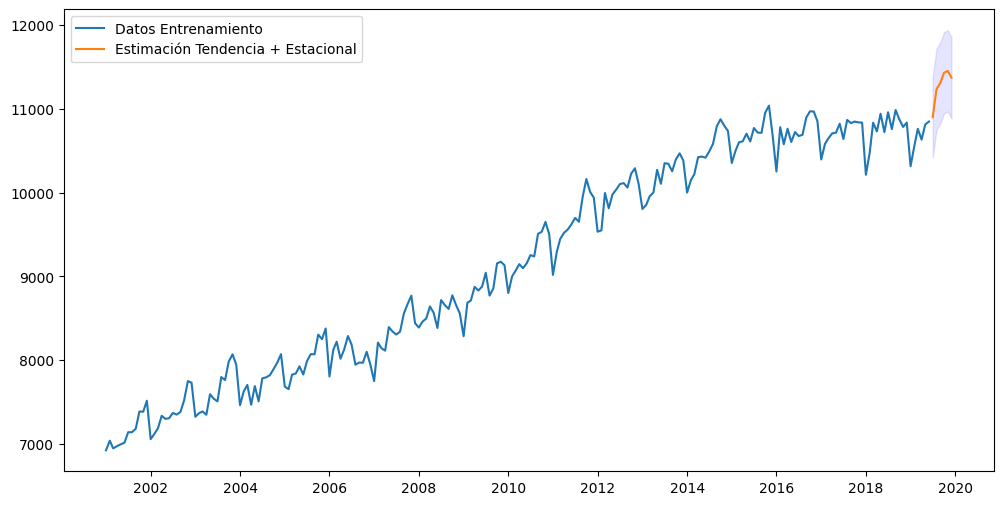

In [81]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Tendencia + Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

### **10. Comparación de modelos**

Para realizar la comparación de los modelos se debe usar una metrica de desempeño, en la clase anterior usamos el RMSE, la comparación se debe hacer fuera de muestra.

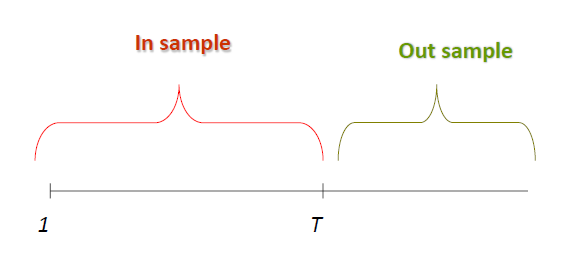

Entrenamiento y prueba

In [82]:
from sklearn.metrics import mean_squared_error

h = 6

train = data.iloc[:-h].copy()
test = data.iloc[-h:].copy()

y_train = train["Ocupados"]
y_test = test["Ocupados"]

Modelo 1. Tendencia lineal

In [83]:
# Tendencia lineal

x_train = np.linspace(1, train.shape[0], train.shape[0])
X_train = sm.add_constant(x_train)

lin = sm.OLS(y_train, X_train)
lin_t = lin.fit()

# Valores futuros para el periodo test
x_test = np.linspace(train.shape[0] + 1, train.shape[0] + h, h)
X_test = sm.add_constant(x_test)

# Predicción sobre test
pred_lin = lin_t.predict(X_test)

# RMSE
rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))

print("RMSE tendencia lineal:", rmse_lin)

RMSE tendencia lineal: 725.5285275153046


Modelo 2. Tendencia cuadrática

In [84]:
# Tendencia cuadrática

train["x"] = np.linspace(1, train.shape[0], train.shape[0])
train["x2"] = train["x"]**2

X_train = sm.add_constant(train[["x", "x2"]])

pol = sm.OLS(y_train, X_train)
pol_2 = pol.fit()

# Valores futuros para el periodo test
x_test = np.linspace(train.shape[0] + 1, train.shape[0] + h, h)

X_test = pd.DataFrame({
    "x": x_test,
    "x2": x_test**2
}, index=test.index)

X_test = sm.add_constant(X_test, has_constant='add')
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Predicción sobre test
pred_pol2 = pol_2.predict(X_test)

# RMSE
rmse_pol2 = np.sqrt(mean_squared_error(y_test, pred_pol2))

print("RMSE tendencia cuadrática:", rmse_pol2)

RMSE tendencia cuadrática: 632.4766573075495


Modelo 3. Estacionalidad

In [85]:
# Modelo solo estacional

month_dummies_train = pd.get_dummies(
    train.index.month,
    drop_first=True,
    dtype=float
).set_index(train.index)

X_train = sm.add_constant(month_dummies_train)

sea = sm.OLS(y_train, X_train)
season = sea.fit()

# Dummies para el periodo test
month_dummies_test = pd.get_dummies(
    test.index.month,
    drop_first=True,
    dtype=float
).set_index(test.index)

month_dummies_test = month_dummies_test.reindex(
    columns=month_dummies_train.columns,
    fill_value=0
)

X_test = sm.add_constant(month_dummies_test, has_constant='add')
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Predicción sobre test
pred_season = season.predict(X_test)

# RMSE
rmse_season = np.sqrt(mean_squared_error(y_test, pred_season))

print("RMSE estacionalidad:", rmse_season)

RMSE estacionalidad: 1685.7662214902105


Modelo 4. Tendencia cuadrática + Estacionalidad

In [86]:
# Tendencia cuadrática + estacionalidad

train["x"] = np.linspace(1, train.shape[0], train.shape[0])
train["x2"] = train["x"]**2

month_dummies_train = pd.get_dummies(
    train.index.month,
    drop_first=True,
    dtype=float
).set_index(train.index)

X_train = sm.add_constant(
    pd.concat([train[["x", "x2"]], month_dummies_train], axis=1)
)

season_pol2 = sm.OLS(y_train, X_train)
season_pol_2 = season_pol2.fit()

# Valores futuros para el periodo test
x_test = np.linspace(train.shape[0] + 1, train.shape[0] + h, h)

x_test_all = pd.DataFrame({
    "x": x_test,
    "x2": x_test**2
}, index=test.index)

month_dummies_test = pd.get_dummies(
    test.index.month,
    drop_first=True,
    dtype=float
).set_index(test.index)

month_dummies_test = month_dummies_test.reindex(
    columns=month_dummies_train.columns,
    fill_value=0
)

X_test = sm.add_constant(
    pd.concat([x_test_all, month_dummies_test], axis=1),
    has_constant='add'
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Predicción sobre test
pred_season_pol2 = season_pol_2.predict(X_test)

# RMSE
rmse_season_pol2 = np.sqrt(mean_squared_error(y_test, pred_season_pol2))

print("RMSE tendencia cuadrática + estacionalidad:", rmse_season_pol2)

RMSE tendencia cuadrática + estacionalidad: 519.2259398377271


Comparación de modelos

In [87]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Tendencia lineal",
        "Tendencia cuadrática",
        "Estacionalidad",
        "Tendencia cuadrática + estacionalidad"
    ],
    "RMSE": [
        rmse_lin,
        rmse_pol2,
        rmse_season,
        rmse_season_pol2
    ]
})

comparacion_modelos.sort_values("RMSE")

,Modelo,RMSE
3,Tendencia cuadrática + estacionalidad,519.225940
1,Tendencia cuadrática,632.476657
0,Tendencia lineal,725.528528
2,Estacionalidad,1685.766221


En este punto podemos validar que el mejor modelo hasta ahora corresponde al modelo 4. Tendencia cuadrática + Estacionalidad, ya que nos arroja un RMSE menor.

### **11. Evaluación de los supuestos de los residuales**

Para poder hacer uso del modelo y los pronósticos se deben cumplir los supuestos del Teorema de Gauss-Markov sobre los residuales de un modelo de regresión múltiple.

- Probar **Autocorrelación** en los **residuales** con las pruebas Box-Pierce y Ljung-Box para los diferentes rezagos.

- Probar **Homoscedasticidad/Heteroscedasticidad** sobre los residuales, una aproximación para determinar si existe un comportamiento GARCH o ARCH es emplear la prueba de Ljung-Box sobre la serie (sin media) al cuadrado. En este caso al ser residuales de una regresión las series ya tienen media cero.

- Probar **Normalidad** sobre los residuales con las pruebas Jarque Bera y Shapiro-Wilk, adicionalmente se pueden realizar las graficas para ver el comportamiento de manera visual.

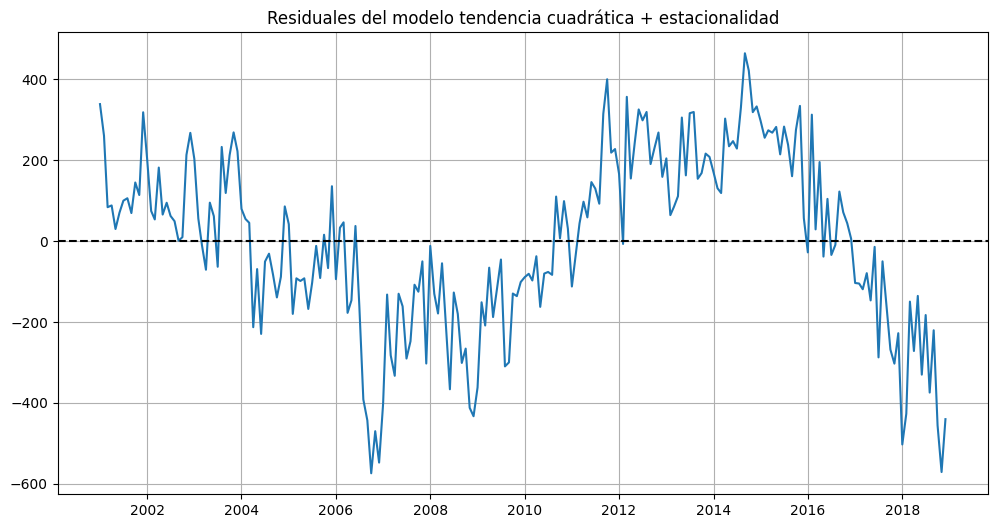

In [90]:
# Residuales del modelo tendencia cuadrática + estacionalidad
residuales = season_pol_2.resid

# Gráfico de los residuales
fig = plt.figure(figsize=(12, 6))

plt.title("Residuales del modelo tendencia cuadrática + estacionalidad")
plt.plot(residuales)
plt.axhline(0, color="black", linestyle="--")
plt.grid()

plt.show()

### **Autocorrelación**

Para determinar si existe autocorrelación vamos a usar la prueba de rachas propuesta por Wald y Wolfowitz, 1940. Es una prueba no paramétrica donde las hipótesis son las siguientes:

$H{0}: ρ = 0$ (Es decir no hay autocorrelación)

$H{1}: ρ \not= 0$ (Es decir hay autocorrelación)

Rechazo $H{0}$ cuando el p-valor es menor al nivel de significancia, convencionalmente se usa un $α$=0.05 ($α$ = nivel de significancia).


In [94]:
signo = residuales>0
runstest_1samp(signo, correction=False)

(np.float64(-11.043439889211447), np.float64(2.35828453450523e-28))

In [95]:
# prueba de Box-Pierce y la modificación de Ljung-Box
sm.stats.acorr_ljungbox(residuales, lags=[1], return_df=True,boxpierce=True ) # Se puede hacer para un solo lag.

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,144.661879,2.546145e-33,142.671119,6.936489e-33


In [96]:
Resul_lb_bp = sm.stats.acorr_ljungbox(residuales, lags=range(1,21), return_df=True,boxpierce=True )
Resul_lb_bp["lb_ho"] = np.where(Resul_lb_bp['lb_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')
Resul_lb_bp["bp_ho"] = np.where(Resul_lb_bp['bp_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')

Resul_lb_bp

,lb_stat,lb_pvalue,bp_stat,bp_pvalue,lb_ho,bp_ho
1,144.661879,2.546145e-33,142.671119,6.936489e-33,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
2,271.578293,1.065425e-59,267.258791,9.236147e-59,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
3,386.748536,1.642084e-83,379.787516,5.284918e-82,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
4,487.442461,3.482459e-104,477.710048,4.431287e-102,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
5,576.287005,2.684743e-122,563.701785,1.404154e-119,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
6,662.139670,9.112349e-140,646.403894,2.268733e-136,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
7,741.155501,9.197755e-156,722.157603,1.150553e-151,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
8,816.178681,6.704436e-171,793.739353,4.600117e-166,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
9,892.894951,2.100330e-186,866.584618,9.775622e-181,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
10,963.082679,1.671827e-200,932.908802,5.250313e-194,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr


El segundo valor corresponde al p-valor, por lo tanto considerando un $α$=0.05, los resultados obtenidos permiten rechazar la hipótesis nula, es decir, la serie no parece comportarse como un ruido blanco, **Presenta autocorrelación**. Esto lo complementamos con la prueba de Box-Pierce y la modificación de Ljung-Box, donde tambien validamos que se rechaza la hipótesis nula. Adicionalmente, con la prueba de 20 rezagos.

### **Homoscedasticidad y Heteroscedasticidad**

Ahora nos queda por chequear si existe problemas de heteroscedasticidad, en
especial un comportamiento tipo ARCH o GARCH, esto implica que la varianza de la serie tenga un comportamiento no autocorrelacionado.

Una aproximación para determinar si existe un comportamiento GARCH o
ARCH es emplear la prueba de Ljung-Box sobre la serie (sin media) al cuadrado.

$H{0}:$ Comportamiento Homoscedastico (Es decir varianza constante)

$H{1}:$ Comportamiento Heteroscedastico (Es decir varianza no constante)


In [97]:
sm.stats.acorr_ljungbox((residuales-residuales.mean())**2, lags=range(1,21), return_df=True,boxpierce=True )

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,80.028580,3.690332e-19,78.927269,6.443913e-19
2,116.545241,4.926319e-26,114.773900,1.194440e-25
3,138.375445,8.466981e-30,136.103411,2.615476e-29
4,146.916858,9.318016e-31,144.409740,3.208954e-30
5,149.844041,1.441197e-30,147.242930,5.155758e-30
6,152.091328,2.794649e-30,149.407748,1.032290e-29
7,152.765311,1.065623e-29,150.053906,3.955420e-29
8,153.549700,3.561966e-29,150.802314,1.333728e-28
9,156.237965,4.487479e-29,153.354932,1.778717e-28
10,157.910659,8.744377e-29,154.935551,3.590517e-28


Los resultados permiten rechazar la hipótesis nula de un comportamiento homoscedástico (no auto-correlación de las varianzas). Es decir, que presentan un comportamiento Heteroscedastico

### **Normalidad**
Finalmente, evaluamos si la serie sigue una distribución normal o no. Primero hacemos un análisis gráfico.

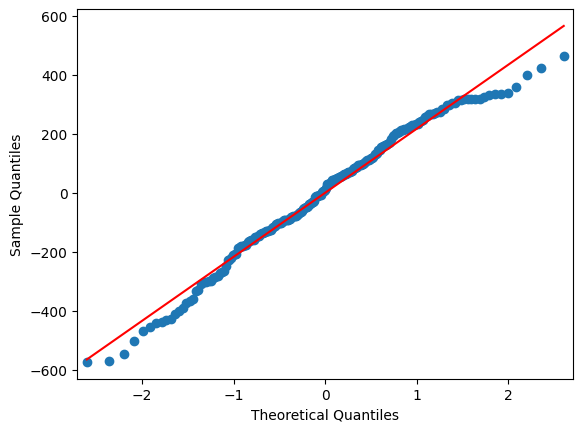

In [99]:
sm.qqplot(residuales, line ='s')
py.show()

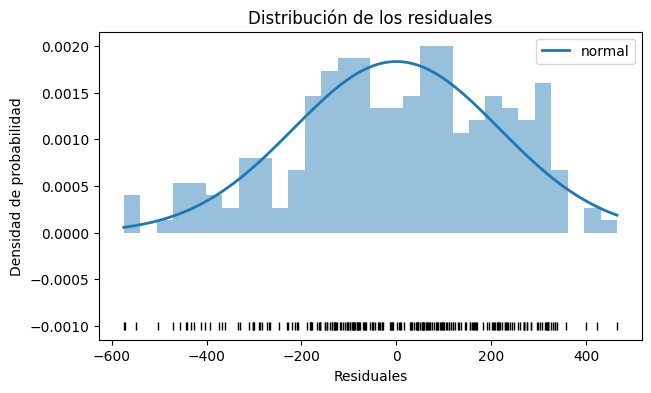

In [104]:
# Histograma + curva normal teórica
# =================================

mu, sigma = stats.norm.fit(residuales)

x_hat = np.linspace(min(residuales), max(residuales), num=100)
y_hat = stats.norm.pdf(x_hat, mu, sigma)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_hat, y_hat, linewidth=2, label='normal')
ax.hist(x=residuales, density=True, bins=30, color="#3182bd", alpha=0.5)
ax.plot(residuales, np.full_like(residuales, -0.001), '|k', markeredgewidth=1)

ax.set_title('Distribución de los residuales')
ax.set_xlabel('Residuales')
ax.set_ylabel('Densidad de probabilidad')
ax.legend()

plt.show()

In [106]:
stats.shapiro(residuales)

ShapiroResult(statistic=np.float64(0.9821525892550219), pvalue=np.float64(0.007824323482242948))

In [107]:
stats.jarque_bera(residuales)

SignificanceResult(statistic=np.float64(5.6128404217892145), pvalue=np.float64(0.060420899789134286))

Las pruebas de normalidad aplicadas a los residuales presentan resultados diferentes. La prueba de Shapiro-Wilk arroja un valor p menor a 0.05, por lo que se rechaza la hipótesis de normalidad. Sin embargo, la prueba de Jarque-Bera presenta un valor p mayor a 0.05, por lo que no se rechaza dicha hipótesis. En conjunto con los graficos, se observa que los residuales tienen un comportamiento aproximadamente normal en la parte central, aunque con desviaciones en las colas. Por lo tanto, la normalidad se cumple de manera aproximada, pero no perfecta.

### **12. Ejercicio en Clase**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses empleando los métodos vistos en la clase. Compare los resultados con el mejor modelo encontrado en el ejercicio anterior.Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.